# Paper figures — consolidated (5 main + 3 appendix)

Each figure answers one claim; ≤2 panels per figure.

In [1]:
import json, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, FancyArrowPatch

import re as _re
REPO = Path('/raid/jupyter-linjimmy1003.md10/UCSD_stress')
# paper/figures/main/ is RESERVED for user's hand-composited final figures (PPT output).
# Auto-generated subfigures land in paper/figures/figN/ where N = figure number.
OUT_ROOT = REPO / 'paper/figures'
OUT_APP  = REPO / 'paper/figures/appendix'
OUT_APP.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 8,
    'axes.titlesize': 9, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.linestyle': ':', 'grid.linewidth': 0.4, 'grid.alpha': 0.5,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'figure.dpi': 110,
})

FM_COLOR = {'labram': '#1f3a5f', 'cbramod': '#B8442C', 'reve': '#2E8B57'}
DS_COLOR = {'stress': '#7A4B00', 'eegmat': '#1F6B6B', 'sleepdep': '#7A4B9C',
            'adftd': '#9467BD', 'tdbrain': '#E377C2'}

CM = 1/2.54
W_SINGLE = 8.9 * CM
W_DOUBLE = 18.3 * CM
FMS = ['labram','cbramod','reve']

def save(fig, name, out_dir=None):
    # Route by fig number in the filename: fig5b_* → paper/figures/fig5/
    # Appendix figures (fig_a1, fig_b2 etc.) go to paper/figures/appendix/
    if out_dir is None:
        m = _re.match(r'fig(\d+)', name)
        if m:
            out_dir = OUT_ROOT / f'fig{m.group(1)}'
        else:
            out_dir = OUT_APP
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir/f'{name}.pdf'); fig.savefig(out_dir/f'{name}.png')
    print(f'saved → {(out_dir/f"{name}.pdf").relative_to(REPO)} + .png')


## Fig 1 — Framework schematic (user-drawn)

Placeholder; will be imported as `fig1_framework_schematic.pdf`.

## Fig 2 — Representation geometry is subject-dominated

**Top**: UMAP 2×3 (3 FM × {Stress, EEGMAT}), points colored by subject — Stress shows tight subject clusters; EEGMAT clusters are looser.
**Bottom**: Subject/Label variance ratio with 95 % bootstrap CI, log-scale; ratio ≫ 1 indicates subject dominance.

saved → paper/figures/fig2/fig2_representation_2x2.pdf + .png


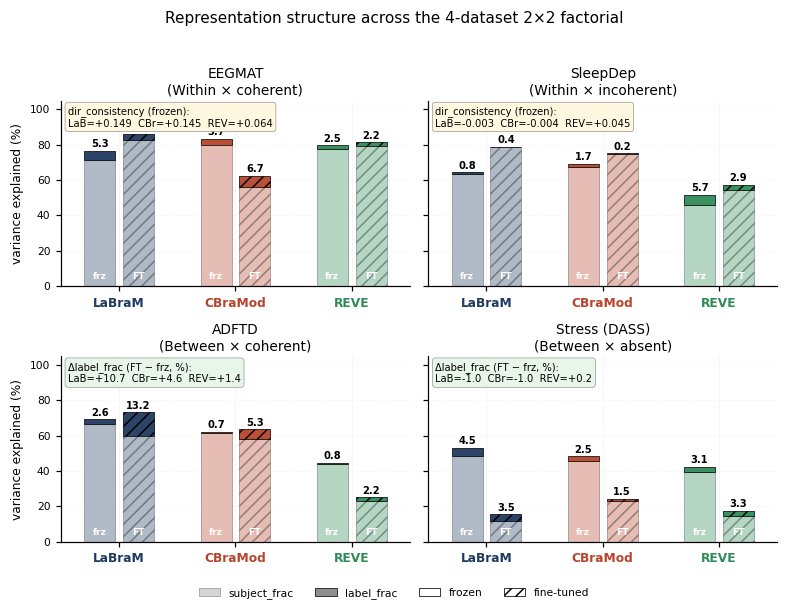

In [2]:
# Fig 2 — Representation structure across the 4-dataset 2×2 factorial
# 2×2 grid: (within|between) × (coherent|absent/incoherent)
# Each panel: variance stacked bars (frz/FT, 3 FMs) + callout (dir_cons or Δlabel_frac)
va      = json.load(open(REPO/'results/final/source_tables/variance_analysis_all.json'))
va_sd   = json.load(open(REPO/'results/final/source_tables/sleepdep_variance_rsa.json'))
dc_main = json.load(open(REPO/'results/final/source_tables/f14_within_subject.json'))
dc_sd   = json.load(open(REPO/'results/final/source_tables/sleepdep_within_subject.json'))

def variance_entry(fm, ds):
    return va_sd.get(f'{fm}_{ds}') if ds == 'sleepdep' else va.get(f'{fm}_{ds}')

def dir_cons(fm, ds):
    if ds == 'eegmat':   return dc_main['frozen']['eegmat'][fm]['dir_consistency']
    if ds == 'sleepdep': return dc_sd['frozen']['sleepdep'][fm]['dir_consistency']
    return None

PANELS = [('eegmat',   'EEGMAT',        'Within × coherent',   'dir_cons'),
          ('sleepdep', 'SleepDep',      'Within × incoherent', 'dir_cons'),
          ('adftd',    'ADFTD',         'Between × coherent',  'delta_label'),
          ('stress',   'Stress (DASS)', 'Between × absent',    'delta_label')]
FM_PRETTY = {'labram': 'LaBraM', 'cbramod': 'CBraMod', 'reve': 'REVE'}

fig, axes = plt.subplots(2, 2, figsize=(W_DOUBLE, W_DOUBLE*0.75), sharey=True)
for ax, (ds, pretty, quadrant, metric) in zip(axes.flat, PANELS):
    for i, fm in enumerate(FMS):
        entry = variance_entry(fm, ds)
        if entry is None: continue
        fs, fl = entry.get('frozen_subject_frac') or 0, entry.get('frozen_label_frac') or 0
        ts, tl = entry.get('ft_subject_frac')     or 0, entry.get('ft_label_frac')     or 0
        ax.bar(3*i,   fs, width=0.8, color=FM_COLOR[fm], alpha=0.35, edgecolor='k', lw=0.5)
        ax.bar(3*i,   fl, width=0.8, bottom=fs, color=FM_COLOR[fm], alpha=0.95, edgecolor='k', lw=0.5)
        ax.bar(3*i+1, ts, width=0.8, color=FM_COLOR[fm], alpha=0.35, edgecolor='k', lw=0.5, hatch='///')
        ax.bar(3*i+1, tl, width=0.8, bottom=ts, color=FM_COLOR[fm], alpha=0.95, edgecolor='k', lw=0.5, hatch='///')
        ax.text(3*i,   fs+fl+2, f'{fl:.1f}', ha='center', fontsize=6.5, fontweight='bold')
        ax.text(3*i+1, ts+tl+2, f'{tl:.1f}', ha='center', fontsize=6.5, fontweight='bold')
        ax.text(3*i,   4, 'frz', ha='center', fontsize=6, color='white', fontweight='bold')
        ax.text(3*i+1, 4, 'FT',  ha='center', fontsize=6, color='white', fontweight='bold')
    ax.set_xticks([3*i+0.5 for i in range(len(FMS))])
    ax.set_xticklabels([FM_PRETTY[fm] for fm in FMS], fontsize=8, fontweight='bold')
    for i, fm in enumerate(FMS): ax.get_xticklabels()[i].set_color(FM_COLOR[fm])
    ax.set_ylim(0, 105); ax.set_xlim(-1, 8)
    if ax in (axes[0,0], axes[1,0]): ax.set_ylabel('variance explained (%)')
    ax.set_title(f'{pretty}\n({quadrant})', fontsize=9, pad=4)
    ax.grid(axis='y', alpha=0.25, lw=0.4)

    if metric == 'dir_cons':
        vals = [(fm, dir_cons(fm, ds)) for fm in FMS]
        s = '  '.join(f'{FM_PRETTY[fm][:3]}={v:+.3f}' for fm, v in vals if v is not None)
        ax.text(0.02, 0.97, f'dir_consistency (frozen):\n{s}', transform=ax.transAxes,
                fontsize=6.5, va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF8E1', edgecolor='#888', lw=0.4))
    else:
        vals = [(fm, (variance_entry(fm, ds) or {}).get('delta_label_frac')) for fm in FMS]
        s = '  '.join(f'{FM_PRETTY[fm][:3]}={v:+.1f}' for fm, v in vals if v is not None)
        ax.text(0.02, 0.97, f'Δlabel_frac (FT − frz, %):\n{s}', transform=ax.transAxes,
                fontsize=6.5, va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#888', lw=0.4))

legend = [Patch(facecolor='#888', alpha=0.35, edgecolor='k', lw=0.5, label='subject_frac'),
          Patch(facecolor='#888', alpha=0.95, edgecolor='k', lw=0.5, label='label_frac'),
          Patch(facecolor='white', edgecolor='k', lw=0.5, label='frozen'),
          Patch(facecolor='white', edgecolor='k', lw=0.5, hatch='///', label='fine-tuned')]
fig.legend(handles=legend, loc='lower center', ncol=4, fontsize=7, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Representation structure across the 4-dataset 2×2 factorial', fontsize=10, y=0.995)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
save(fig, 'fig2_representation_2x2')

## Fig 3 — Honest evaluation closes the Wang gap

**Left**: funnel collapse — Wang 0.9047 → 3-FM subject-disjoint range → perm-null baseline → classical XGBoost.
**Right**: LaBraM permutation-null densities; red line = real score; p-value annotated.

saved → paper/figures/fig3/fig3_honest_evaluation.pdf + .png


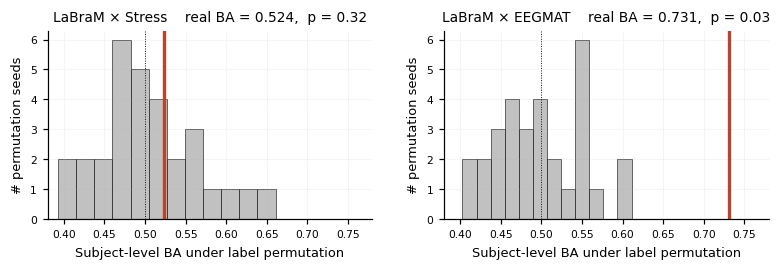

In [3]:
# Fig 3 — Honest evaluation: permutation null shows chance on Stress, signal on EEGMAT
# Funnel dropped — Wang gap & absolute BAs now in Table 1. Fig 3 owns the statistical claim only.

null_dir = REPO/'results/studies/exp27_paired_null/stress'
nulls_stress = np.array([json.load(open(d/'summary.json'))['subject_bal_acc']
                         for d in sorted(null_dir.iterdir()) if (d/'summary.json').exists()])
null_dir_e = REPO/'results/studies/exp27_paired_null/eegmat'
nulls_eeg = np.array([json.load(open(d/'summary.json'))['subject_bal_acc']
                      for d in sorted(null_dir_e.iterdir()) if (d/'summary.json').exists()])

fp = json.load(open(REPO/'results/studies/exp_30_sdl_vs_between/tables/fm_performance.json'))
def real_ft(ds, fm='labram'):
    rows = [r for r in fp if r['dataset']==ds and r['fm']==fm and r['mode']=='ft' and r['bal_acc'] is not None]
    return float(np.mean([r['bal_acc'] for r in rows]))
real_s, real_e = real_ft('stress'), real_ft('eegmat')

fig, axes = plt.subplots(1, 2, figsize=(W_DOUBLE, W_DOUBLE*0.34),
                         gridspec_kw={'wspace': 0.22, 'left': 0.07, 'right': 0.98,
                                      'top': 0.90, 'bottom': 0.20})
for ax, nulls, real, ds in [(axes[0], nulls_stress, real_s, 'Stress'),
                             (axes[1], nulls_eeg, real_e, 'EEGMAT')]:
    ax.hist(nulls, bins=12, color='#BBBBBB', edgecolor='k', lw=0.4, alpha=0.9)
    ax.axvline(real, color='#B8442C', lw=2.2)
    ax.axvline(0.5, color='k', ls=':', lw=0.6)
    k = int(np.sum(nulls >= real)); p = (k+1)/(len(nulls)+1)
    ax.set_title(f'LaBraM × {ds}    real BA = {real:.3f},  p = {p:.2f}', fontsize=9)
    ax.set_xlabel('Subject-level BA under label permutation', fontsize=8.5)
    ax.set_ylabel('# permutation seeds', fontsize=8.5)
    ax.set_xlim(0.38, 0.78)
save(fig, 'fig3_honest_evaluation')


## Fig 4 — Contrast-anchoring in both eval regimes

**Top**: between-subject dot plot — 3 FM × 2 DS, 3-seed mean ± SD, subject-disjoint 5-fold.
**Bottom**: within-subject feature-space trajectory × 6 cells — EEGMAT (rest→task) arrows align; Stress (low→high DSS) arrows scramble. `dir_consistency` printed per panel.

/raid/jupyter-linjimmy1003.md10/.conda/envs/stress/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/raid/jupyter-linjimmy1003.md10/.conda/envs/stress/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/raid/jupyter-linjimmy1003.md10/.conda/envs/stress/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


saved → paper/figures/fig4/fig4a_eegmat_trajectory.pdf + .png


/raid/jupyter-linjimmy1003.md10/.conda/envs/stress/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/raid/jupyter-linjimmy1003.md10/.conda/envs/stress/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/raid/jupyter-linjimmy1003.md10/.conda/envs/stress/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


saved → paper/figures/fig4/fig4b_sleepdep_trajectory.pdf + .png
saved → paper/figures/fig4/fig4c_dir_consistency.pdf + .png


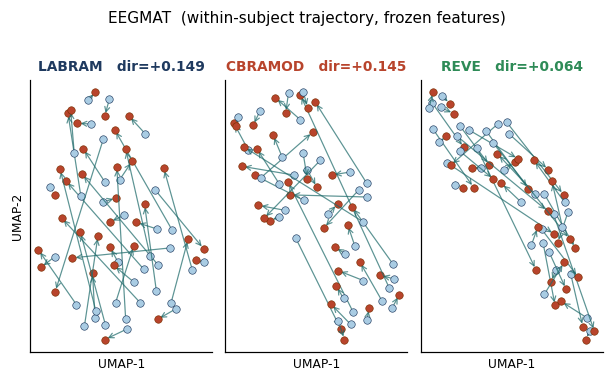

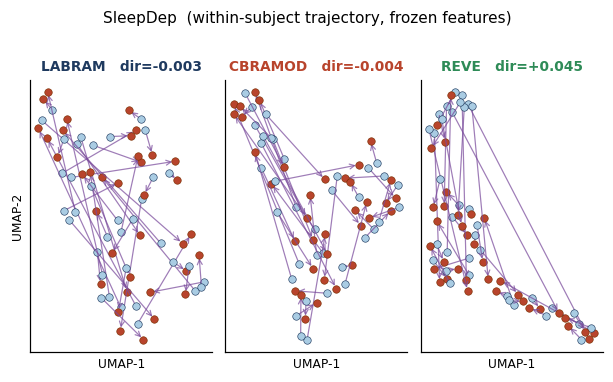

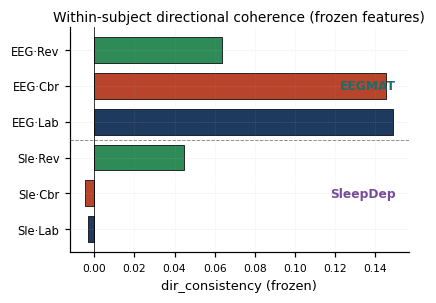

In [4]:
# Fig 4 — Within-subject contrast-anchoring (EEGMAT + SleepDep only)
# Each sub-panel saved as separate PDF for PPT composition; no gridspec overlap.
# Stress / ADFTD excluded — dir_consistency undefined for between-subject labels.
import umap

def load_feat(fm, ds):
    ch = 30 if ds=='stress' else 19
    d = np.load(REPO/f'results/features_cache/frozen_{fm}_{ds}_{ch}ch.npz', allow_pickle=True)
    return d['features'], d['labels'], d['patient_ids']

def umap2(X, seed=42):
    return umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.25,
                     random_state=seed, metric='cosine').fit_transform(X)

def paired_endpoints(pids, y2):
    pairs = []
    for s in np.unique(pids):
        m = (pids==s)
        if m.sum() < 2 or len(np.unique(y2[m])) != 2: continue
        lo_c = np.where(m & (y2==0))[0]
        hi_c = np.where(m & (y2==1))[0]
        if len(lo_c)==0 or len(hi_c)==0: continue
        pairs.append((lo_c[0], hi_c[0]))
    return pairs

sup = json.load(open(REPO/'results/studies/exp11_longitudinal_dss/within_subject_supplementary.json'))
sd_sup = json.load(open(REPO/'results/final/source_tables/sleepdep_within_subject.json'))
for mode in ['frozen', 'ft']:
    sup[mode]['sleepdep'] = sd_sup[mode]['sleepdep']

ARROW_COLOR = {'eegmat': '#1F6B6B', 'sleepdep': '#7A4B9C'}

# ---- Fig 4a / 4b: per-dataset trajectory strip (1 row × 3 FMs, one PDF each) ----
def trajectory_strip(ds, pretty, out_name):
    fig, axes = plt.subplots(1, 3, figsize=(W_DOUBLE*0.78, W_SINGLE*0.95))
    for ax, fm in zip(axes, FMS):
        X, y2, pids = load_feat(fm, ds)
        emb = umap2(X)
        ax.scatter(emb[:,0], emb[:,1], s=9, c='#CCC', alpha=0.55, edgecolors='none')
        for lo, hi in paired_endpoints(pids, y2):
            ax.annotate('', xy=emb[hi], xytext=emb[lo],
                        arrowprops=dict(arrowstyle='->', color=ARROW_COLOR[ds],
                                        lw=0.8, alpha=0.72))
            ax.scatter(*emb[lo], s=24, c='#A9CCE3', edgecolors='#1f3a5f', linewidths=0.4, zorder=3)
            ax.scatter(*emb[hi], s=24, c='#B8442C', edgecolors='#7A2F00', linewidths=0.4, zorder=3)
        dc = sup['frozen'][ds][fm]['dir_consistency']
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'{fm.upper()}   dir={dc:+.3f}', fontsize=9, color=FM_COLOR[fm], fontweight='bold')
    axes[0].set_ylabel('UMAP-2', fontsize=8)
    for ax in axes: ax.set_xlabel('UMAP-1', fontsize=8)
    fig.suptitle(f'{pretty}  (within-subject trajectory, frozen features)', fontsize=10, y=1.02)
    plt.tight_layout()
    save(fig, out_name)

trajectory_strip('eegmat',   'EEGMAT',   'fig4a_eegmat_trajectory')
trajectory_strip('sleepdep', 'SleepDep', 'fig4b_sleepdep_trajectory')

# ---- Fig 4c: dir_consistency comparison horizontal bar (standalone) ----
fig, ax = plt.subplots(figsize=(W_SINGLE*1.1, W_SINGLE*0.8))
labels, colors, values = [], [], []
# Order so EEGMAT (coherent) sits on top
for ds, pretty in [('sleepdep', 'SleepDep'), ('eegmat', 'EEGMAT')]:
    for fm in FMS:
        labels.append(f'{pretty[:3]}·{fm[:3].capitalize()}')
        colors.append(FM_COLOR[fm])
        values.append(sup['frozen'][ds][fm]['dir_consistency'])
ypos = np.arange(len(labels))
ax.barh(ypos, values, color=colors, edgecolor='k', lw=0.5, height=0.72)
# horizontal divider between the 2 datasets (between index 2 and 3)
ax.axhline(2.5, color='#888', lw=0.6, ls='--')
ax.axvline(0, color='k', lw=0.5)
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xlabel('dir_consistency (frozen)', fontsize=8.5)
ax.set_title('Within-subject directional coherence (frozen features)', fontsize=9, pad=4)
ax.grid(axis='x', alpha=0.3, lw=0.4)
# dataset group labels (outside y-axis, on right side)
xlim = ax.get_xlim()
ax.text(xlim[1]*0.96, 1.0, 'SleepDep', va='center', ha='right', fontsize=8,
        fontweight='bold', color=ARROW_COLOR['sleepdep'])
ax.text(xlim[1]*0.96, 4.0, 'EEGMAT',   va='center', ha='right', fontsize=8,
        fontweight='bold', color=ARROW_COLOR['eegmat'])
plt.tight_layout()
save(fig, 'fig4c_dir_consistency')


## Fig 5 — Causal anchor dissection (split into 3 separate subfigures)

Each subfigure is saved as its own PDF/PNG so they can be laid out in PowerPoint without overlap. Preamble below loads the shared data (PSD + probe + band-stop).

In [5]:
# Fig 5 preamble — shared loaders for PSD, FOOOF probe scatter, band-stop
from scipy.signal import welch

SFREQ = 200; FMIN, FMAX = 1, 50
def mean_psd(sig):
    s = sig.reshape(-1, sig.shape[-1])
    f, P = welch(s, fs=SFREQ, nperseg=min(512, s.shape[-1]), axis=-1)
    m = (f>=FMIN) & (f<=FMAX); return f[m], P.mean(axis=0)[m]

def rep_psd(ds):
    p = REPO/f'results/features_cache/fooof_ablation/{ds}_norm_none.npz'
    d = np.load(p, allow_pickle=True)
    ri = int(d['quality_r2'].mean(axis=1).argmax())
    mask = d['window_rec_idx']==ri
    f,P_ap = mean_psd(d['periodic_removed'][mask])
    _,P_pe = mean_psd(d['aperiodic_removed'][mask])
    b = float(d['aperiodic_b'][ri].mean()); chi = float(d['aperiodic_chi'][ri].mean())
    return dict(f=f, ap=P_ap, pe=P_pe, fit=10**b/(f**chi), chi=chi)

# All 4 datasets now have FOOOF ablation + band-stop caches (ADFTD retrofit 2026-04-21)
DS_PSD   = ['eegmat','sleepdep','stress','adftd']
DS_PROBE = ['eegmat','sleepdep','stress','adftd']
DS_BAND  = ['eegmat','sleepdep','stress','adftd']

DS_SHORT = {'eegmat':'EEGMAT','sleepdep':'SleepDep','stress':'Stress','adftd':'ADFTD'}
DS_CMAP  = {'eegmat':'#2E8B8B','sleepdep':'#7A4B9C','stress':'#D55E00','adftd':'#1F77B4'}

psd = {ds: rep_psd(ds) for ds in DS_PSD}
F = {ds: json.load(open(REPO/f'results/studies/fooof_ablation/{ds}_probes.json'))['results']
     for ds in DS_PROBE}
bs = json.load(open(REPO/'results/studies/exp14_channel_importance/band_stop_ablation.json'))


### Fig 5a — PSD + FOOOF fit (4 datasets)

ADFTD added alongside EEGMAT / SleepDep / Stress. Aperiodic fit dashed, periodic peaks shaded.

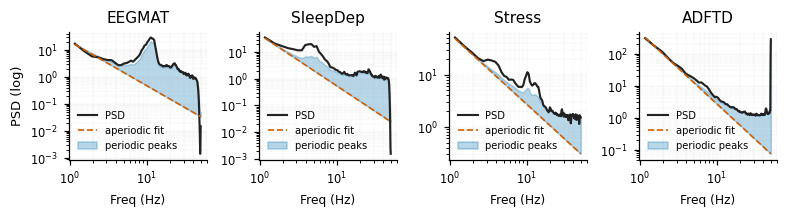

saved → paper/figures/fig5/fig5a_psd_fooof_fit.pdf + .png


In [6]:
# Fig 5a — PSD + FOOOF fit per dataset (separate subfigure)
fig, axes = plt.subplots(1, len(DS_PSD),
                         figsize=(W_DOUBLE, W_DOUBLE*0.28), sharey=False)
for ax, ds in zip(axes, DS_PSD):
    d = psd[ds]
    ax.loglog(d['f'], d['ap']+d['pe'], color='#222', lw=1.4, label='PSD')
    ax.loglog(d['f'], d['fit'], color='#D55E00', ls='--', lw=1.1, label='aperiodic fit')
    ax.fill_between(d['f'], d['fit'], d['fit']+d['pe'], color='#0072B2',
                    alpha=0.28, label='periodic peaks')
    ax.set_xlabel('Freq (Hz)', fontsize=8)
    ax.set_title(DS_SHORT[ds], fontsize=10)
    ax.tick_params(labelsize=7.5)
    ax.legend(fontsize=6.5, loc='lower left', frameon=False)
    ax.grid(True, which='both', ls=':', lw=0.3, alpha=0.5)
axes[0].set_ylabel('PSD (log)', fontsize=8.5)
plt.tight_layout()
plt.show()
save(fig, 'fig5a_psd_fooof_fit')


### Fig 5b — FOOOF ablation signature per FM (Δ BA in pp)

Each panel = one FM with its native input norm (LaBraM zscore, CBraMod/REVE raw). Point = (Δ subject-ID probe BA, Δ state probe BA) in percentage points for 4 datasets × 2 ablation conditions (circle: −aperiodic, square: −periodic).

**Read within-FM only**: directional patterns and dataset ordering within one panel are reliable. Cross-FM magnitude comparison is **not fair** because the three FMs use different input-norm conventions by pretraining design; zscore flattens aperiodic amplitude while raw/internal-scale paths retain it. A zscore-control ablation is deferred (see Section 6 Limitations).

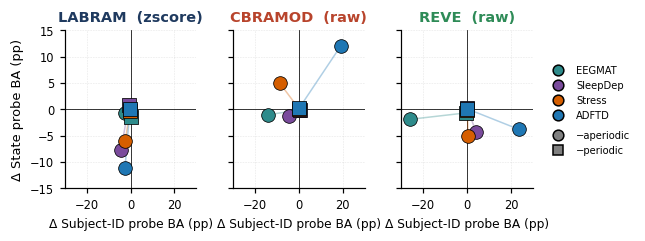

saved → paper/figures/fig5/fig5b_fooof_scatter.pdf + .png


In [7]:
# Fig 5b — FOOOF ablation signature per FM (Δ BA, pp)
fig, axes = plt.subplots(1, 3, figsize=(W_DOUBLE*0.82, W_SINGLE*0.65), sharex=True, sharey=True)
markers = {'−aperiodic':'o','−periodic':'s'}
COND_MAP = [('aperiodic_removed','−aperiodic'),('periodic_removed','−periodic')]

for ax, fm in zip(axes, FMS):
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    for ds in DS_PROBE:
        pts = []
        for cond, short in COND_MAP:
            dsub = (F[ds][fm][cond]['subject_probe_mean'] - F[ds][fm]['original']['subject_probe_mean'])*100
            dsta = (F[ds][fm][cond]['state_probe_mean'] - F[ds][fm]['original']['state_probe_mean'])*100
            pts.append((short, dsub, dsta))

        ax.plot([p[1] for p in pts], [p[2] for p in pts], color=DS_CMAP[ds], lw=1.0, alpha=0.35)
        for short, dsub, dsta in pts:
            ax.scatter(dsub, dsta, s=80, color=DS_CMAP[ds], marker=markers[short], edgecolor='k', lw=0.5, zorder=3)

    ax.set_title(f"{fm.upper()}  ({'zscore' if fm=='labram' else 'raw'})", fontsize=9.5, color=FM_COLOR[fm], fontweight='bold')
    ax.set_xlabel('Δ Subject-ID probe BA (pp)', fontsize=8)
    ax.tick_params(labelsize=7.5)

axes[0].set_ylabel('Δ State probe BA (pp)', fontsize=8.5)
axes[0].set_xlim(-30, 30)
axes[0].set_ylim(-15, 15)

ds_leg = [Line2D([],[], marker='o', ls='', color=DS_CMAP[d], markeredgecolor='k', markersize=7, label=DS_SHORT[d]) for d in DS_PROBE]
cond_leg = [Line2D([],[], marker='o', ls='', color='gray', markeredgecolor='k', markersize=7, label='−aperiodic'),
            Line2D([],[], marker='s', ls='', color='gray', markeredgecolor='k', markersize=7, label='−periodic')]

fig.legend(handles=ds_leg, loc='center left', bbox_to_anchor=(0.83, 0.6), fontsize=6.5, frameon=False)
fig.legend(handles=cond_leg, loc='center left', bbox_to_anchor=(0.83, 0.4), fontsize=6.5, frameon=False)

fig.subplots_adjust(left=0.1, right=0.82, bottom=0.22, top=0.85, wspace=0.28)
plt.show()
save(fig, 'fig5b_fooof_scatter')


### Fig 5c — Band-stop cosine distance per FM

Cosine distance between original and band-stopped FM features across delta/theta/alpha/beta. Each FM has its own y-axis (REVE ~40× LaBraM in raw µV scale).

**Read within-FM only**: which band peaks within a given panel is the interpretable signal. Cross-FM magnitudes reflect input-norm differences, not relative spectral attention.

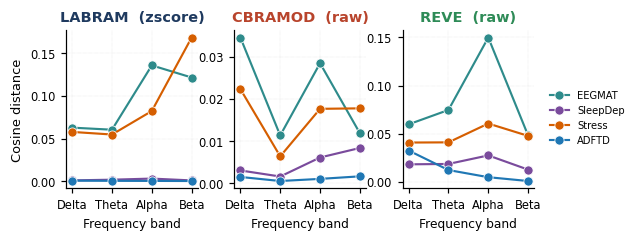

saved → paper/figures/fig5/fig5c_band_stop.pdf + .png


In [8]:
# Fig 5c — Band-stop cosine distance per FM (3-panel strip, raw scale)
BANDS = ['delta','theta','alpha','beta']
xi = np.arange(len(BANDS))
fig, axes = plt.subplots(1, 3, figsize=(W_DOUBLE*0.82, W_SINGLE*0.65), sharex=True)

for ax, fm in zip(axes, FMS):
    for ds in DS_BAND:
        v = [bs[ds][fm][b]['mean_distance'] for b in BANDS]
        ax.plot(xi, v, '-o', color=DS_CMAP[ds], lw=1.4, ms=6,
                markeredgecolor='white', markeredgewidth=0.5, label=DS_SHORT[ds])
    ax.set_xticks(xi)
    ax.set_xticklabels([b.title() for b in BANDS], fontsize=7.5)
    ax.set_xlabel('Frequency band', fontsize=8)
    ax.set_title(f"{fm.upper()}  ({'zscore' if fm=='labram' else 'raw'})",
                 fontsize=9.5, color=FM_COLOR[fm], fontweight='bold')
    ax.grid(True, ls=':', lw=0.3, alpha=0.5)
    ax.tick_params(labelsize=7.5)

axes[0].set_ylabel('Cosine distance', fontsize=8.5)

h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, fontsize=6.5, frameon=False, loc='center left', bbox_to_anchor=(0.83, 0.5))

fig.subplots_adjust(left=0.1, right=0.82, bottom=0.22, top=0.85, wspace=0.28)
plt.show()
save(fig, 'fig5c_band_stop')


## Fig 6 — Stress collapse mechanism

**Left**: Architecture ceiling — 4 classical ML + 2 non-FM deep + 3 FMs, param count log-scale. All sit within the 0.43–0.58 band.
**Right**: LP→FT representation drift — each arrow goes from LP (hollow circle) to FT (filled) in (label_frac, subject_frac) space; colour = mechanism verdict (shortcut / label / no-drift).

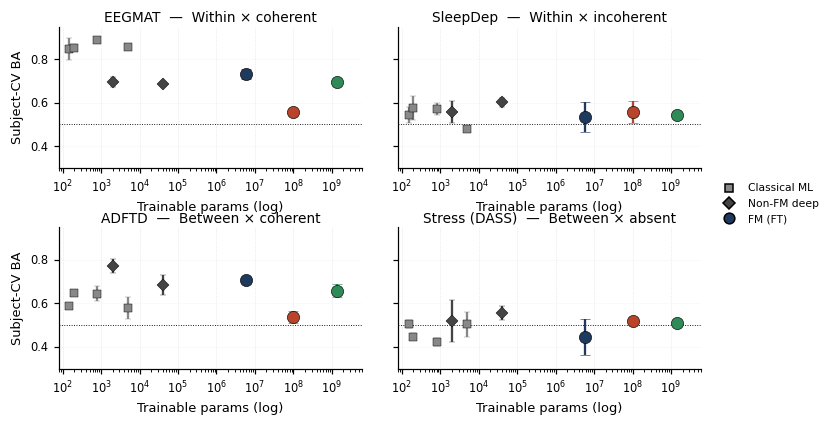

saved → paper/figures/fig6/fig6_architecture_ceiling.pdf + .png


In [9]:
# Fig 6 — Architecture ceiling × 3 regimes
# Each panel: classical ML (squares) + non-FM deep (diamonds) + FM FT (colored circles)
# x = params (log), y = subject-CV BA, one panel per dataset (by regime order).

# --- Data sources -----------------------------------------------------------
t1 = json.load(open(REPO/'paper/tables/_source/table1_master_performance.json'))  # FM LP/FT per dataset

def fm_ft(ds, fm):
    k = f'{ds}_{fm}'
    r = t1.get(k, {}).get('ft')
    if r is None: return None
    return (float(r['mean']), float(r.get('std') or 0))

# Classical multi-seed (new format, 3 datasets; ADFTD not run yet)
def classical(ds):
    p = REPO/f'results/studies/exp02_classical_dass/{ds}/summary.json'
    if not p.exists(): return []
    d = json.load(open(p))
    agg = d.get('aggregated', {})
    out = []
    for name in ['LogReg_L2','SVM_RBF','RF','XGBoost']:
        if name in agg:
            out.append((name, agg[name]['mean_bal_acc'], agg[name]['std_bal_acc']))
    return out

# Non-FM deep (eegnet, shallowconvnet) — dataset-specific subdirs; Stress uses sweep (legacy)
def nonfm(ds):
    if ds == 'stress':
        base = REPO/'results/studies/exp15_nonfm_baselines/sweep'
        candidates = {'eegnet': 'eegnet_lr5e-4', 'shallowconvnet': 'shallowconvnet_lr1e-4'}
    else:  # eegmat / sleepdep / adftd
        base = REPO/f'results/studies/exp15_nonfm_baselines/{ds}'
        candidates = {'eegnet': 'eegnet_lr1e-3', 'shallowconvnet': 'shallowconvnet_lr5e-4'}
    out = {}
    for arch, stem in candidates.items():
        vals = []
        for sub in base.glob(f'{stem}_s*'):
            s = sub/'summary.json'
            if s.exists():
                try: vals.append(json.load(open(s))['subject_bal_acc'])
                except: pass
        if vals:
            out[arch] = (float(np.mean(vals)),
                         float(np.std(vals, ddof=1)) if len(vals)>1 else 0)
    return out

ARCH_PARAMS = {'LogReg_L2': 150, 'SVM_RBF': 200, 'RF': 800, 'XGBoost': 5000,
               'eegnet': 2e3, 'shallowconvnet': 4e4,
               'labram': 5.8e6, 'cbramod': 1e8, 'reve': 1.4e9}
NAME_SHORT = {'LogReg_L2':'LR', 'SVM_RBF':'SVM', 'RF':'RF', 'XGBoost':'XGB'}

# 2×2 layout (top=within, bottom=between; left=coherent, right=absent/incoherent)
PANELS = [('eegmat',   'EEGMAT',        'Within × coherent'),
          ('sleepdep', 'SleepDep',      'Within × incoherent'),
          ('adftd',    'ADFTD',         'Between × coherent'),
          ('stress',   'Stress (DASS)', 'Between × absent')]

# --- FIGURE -----------------------------------------------------------------
fig = plt.figure(figsize=(W_DOUBLE, W_DOUBLE*0.52))
gs  = fig.add_gridspec(2, 2, left=0.07, right=0.88, top=0.93, bottom=0.10,
                       wspace=0.12, hspace=0.42)

for idx, (ds, pretty, regime) in enumerate(PANELS):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])
    ax.axhline(0.5, color='k', ls=':', lw=0.6, zorder=0)

    for name, m, s in classical(ds):
        ax.errorbar(ARCH_PARAMS[name], m, yerr=s, fmt='s', color='#888', ms=5,
                    capsize=2, markeredgecolor='k', markeredgewidth=0.3, zorder=3)

    for arch, (m, s) in nonfm(ds).items():
        ax.errorbar(ARCH_PARAMS[arch], m, yerr=s, fmt='D', color='#444', ms=6,
                    capsize=2, markeredgecolor='k', markeredgewidth=0.3, zorder=3)

    for fm in FMS:
        res = fm_ft(ds, fm)
        if res is None: continue
        m, s = res
        ax.errorbar(ARCH_PARAMS[fm], m, yerr=s, fmt='o', color=FM_COLOR[fm], ms=8,
                    capsize=3, markeredgecolor='k', markeredgewidth=0.4, zorder=4)

    ax.set_xscale('log')
    ax.set_xlim(80, 6e9)
    ax.set_ylim(0.30, 0.95)
    ax.set_xlabel('Trainable params (log)', fontsize=8.5)

    if col == 0:
        ax.set_ylabel('Subject-CV BA', fontsize=8.5)
    else:
        ax.set_yticklabels([])

    ax.set_title(f'{pretty}  —  {regime}', fontsize=9, pad=3)
    ax.tick_params(labelsize=7.5)
    ax.grid(axis='y', alpha=0.25, lw=0.4)

legend_marks = [Line2D([],[],marker='s',ls='',color='#888',markeredgecolor='k',ms=5,label='Classical ML'),
                Line2D([],[],marker='D',ls='',color='#444',markeredgecolor='k',ms=6,label='Non-FM deep'),
                Line2D([],[],marker='o',ls='',color='#1f3a5f',markeredgecolor='k',ms=7,label='FM (FT)')]

fig.legend(handles=legend_marks, fontsize=7, loc='center left', bbox_to_anchor=(0.89, 0.5), frameon=False)

plt.show()
save(fig, 'fig6_architecture_ceiling')


## Appendix A.1 — Disease cohort variance atlas

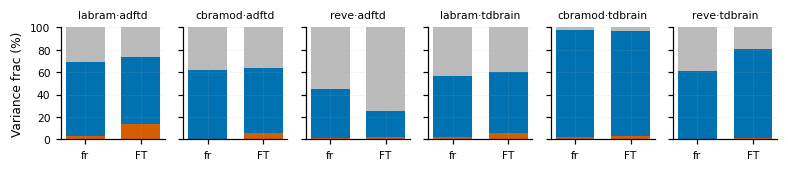

saved → paper/figures/appendix/figA1_variance_atlas_disease.pdf + .png


In [10]:
# Fig A.1 — ADFTD + TDBRAIN variance atlas
va = json.load(open(REPO/'results/final/source_tables/variance_analysis_all.json'))
DATASETS = ['adftd','tdbrain']
fig, axes = plt.subplots(2, 6, figsize=(W_DOUBLE, W_DOUBLE*0.38), sharey='row')
for col, (fm,ds) in enumerate([(fm,ds) for ds in DATASETS for fm in FMS]):
    c = va[f'{fm}_{ds}']
    ax = axes[0,col]
    fr_l, fr_s = c['frozen_label_frac'], c['frozen_subject_frac']
    ft_l, ft_s = c['ft_label_frac'], c['ft_subject_frac']
    for i,(l,sb,r) in enumerate([(fr_l, fr_s, max(0,100-fr_l-fr_s)),(ft_l, ft_s, max(0,100-ft_l-ft_s))]):
        ax.bar(i, l, color='#D55E00', width=0.7)
        ax.bar(i, sb, bottom=l, color='#0072B2', width=0.7)
        ax.bar(i, r, bottom=l+sb, color='#BBBBBB', width=0.7)
    ax.set_xticks([0,1]); ax.set_xticklabels(['fr','FT'])
    ax.set_title(f'{fm}·{ds}', fontsize=7)
    ax.set_ylim(0, 100)
    if col==0: ax.set_ylabel('Variance frac (%)')
    axes[1,col].set_visible(False)
plt.tight_layout(); plt.show()
save(fig, 'figA1_variance_atlas_disease', out_dir=OUT_APP)


## Appendix B.1 — Channel ablation topomap (Stress)

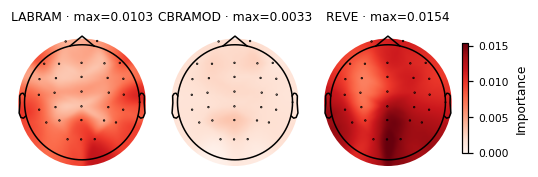

saved → paper/figures/appendix/figB1_channel_ablation.pdf + .png


In [11]:
# Fig B.1 — Channel ablation topomap (Stress 30-ch, 3 FMs)
import mne
ci = json.load(open(REPO/'results/studies/exp14_channel_importance/channel_importance.json'))
RAW = ci['labram']['channel_names']
montage = mne.channels.make_standard_montage('standard_1005')
mont_map = {c.lower(): c for c in montage.ch_names}
CH = [mont_map.get(c.lower(), c) for c in RAW]
info = mne.create_info(CH, 200, ch_types='eeg'); info.set_montage(montage, on_missing='warn')

fig, axes = plt.subplots(1, 3, figsize=(W_DOUBLE*0.85, W_DOUBLE*0.3))
vmax = max(max(ci[fm]['mean_importance']) for fm in FMS)
for ax, fm in zip(axes, FMS):
    imp = np.array(ci[fm]['mean_importance'])
    im, _ = mne.viz.plot_topomap(imp, info, axes=ax, show=False, cmap='Reds',
                                  vlim=(0, vmax), contours=0, sensors=True)
    ax.set_title(f'{fm.upper()} · max={imp.max():.4f}', fontsize=8)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, pad=0.02, label='Importance')
plt.show()
save(fig, 'figB1_channel_ablation', out_dir=OUT_APP)


## Appendix B.2 — Per-FM band-stop breakdown (3 datasets)

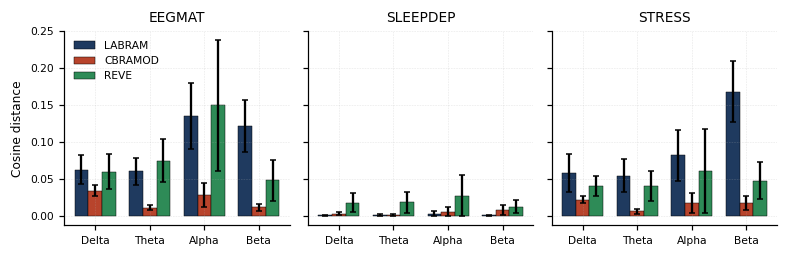

saved → paper/figures/appendix/figB2_band_stop_breakdown.pdf + .png


In [12]:
# Fig B.2 — Per-FM band-stop breakdown (3 datasets × 3 FM × 4 bands)
bs = json.load(open(REPO/'results/studies/exp14_channel_importance/band_stop_ablation.json'))
BANDS = ['delta','theta','alpha','beta']
fig, axes = plt.subplots(1, 3, figsize=(W_DOUBLE, W_DOUBLE*0.33), sharey=True)
w = 0.25; x = np.arange(len(BANDS))
for ax, ds in zip(axes, ['eegmat','sleepdep','stress']):
    for i, fm in enumerate(FMS):
        vals = [bs[ds][fm][b]['mean_distance'] for b in BANDS]
        errs = [bs[ds][fm][b]['std_distance'] for b in BANDS]
        ax.bar(x + (i-1)*w, vals, w, yerr=errs, capsize=2, color=FM_COLOR[fm],
               edgecolor='k', lw=0.3, label=fm.upper() if ds=='eegmat' else None)
    ax.set_xticks(x); ax.set_xticklabels([b.title() for b in BANDS], fontsize=7)
    ax.set_title(ds.upper(), fontsize=9)
axes[0].set_ylabel('Cosine distance'); axes[0].legend(frameon=False, fontsize=7)
plt.tight_layout(); plt.show()
save(fig, 'figB2_band_stop_breakdown', out_dir=OUT_APP)
